Day 7 — Task Sheet
NumPy Advanced: Aggregations & Linear Algebra

Part A — the curriculum activities

In [ ]:
# TASK 01
# Statistics along axes, on multi-dimensional data

import numpy as np 

# Seed the random generator for reproducible results
rng = np.random.default_rng(42)

# 4 shops × 30 days × 3 product categories
sales = rng.integers(50, 500, size=(4, 30, 3))

print("Original sales shape:", sales.shape)
# Expected: (4, 30, 3)


# ---------------------------------------------------------
# 1. Total sales per shop
# Collapse days (axis=1) and product categories (axis=2)
# ---------------------------------------------------------
per_shop = sales.sum(axis=(1, 2))

print("\nTotal sales per shop:")
print(per_shop)
print("Shape:", per_shop.shape)
# Expected: (4,)


# ---------------------------------------------------------
# 2. Average daily sales per category
# Collapse shops (axis=0) and days (axis=1)
# ---------------------------------------------------------
avg_per_category = sales.mean(axis=(0, 1))

print("\nAverage daily sales per category:")
print(avg_per_category)
print("Shape:", avg_per_category.shape)
# Expected: (3,)


# ---------------------------------------------------------
# 3. Best day for each shop
# First collapse product categories (axis=2)
# Result: one total for every shop/day
# ---------------------------------------------------------
daily_shop_totals = sales.sum(axis=2)

print("\nDaily totals per shop:")
print(daily_shop_totals)
print("Shape:", daily_shop_totals.shape)
# Expected: (4, 30)

best_day_per_shop = np.argmax(daily_shop_totals, axis=1)

print("\nBest day index for each shop:")
print(best_day_per_shop)
print("Shape:", best_day_per_shop.shape)
# Expected: (4,)

# Convert zero-based index to human-readable day number
print("Best day number for each shop:")
print(best_day_per_shop + 1)


# ---------------------------------------------------------
# 4. Most consistent shop
# Find standard deviation of daily totals for each shop
# ---------------------------------------------------------
daily_std_per_shop = daily_shop_totals.std(axis=1)

print("\nStandard deviation of daily totals:")
print(daily_std_per_shop)
print("Shape:", daily_std_per_shop.shape)
# Expected: (4,)

most_consistent_shop = np.argmin(daily_std_per_shop)

print("\nMost consistent shop:")
print(f"Shop {most_consistent_shop + 1}")
print(f"Standard deviation: {daily_std_per_shop[most_consistent_shop]:.2f}")


# ---------------------------------------------------------
# 5. keepdims=True
# Calculate each shop's average daily total
# ---------------------------------------------------------
shop_daily_mean = daily_shop_totals.mean(axis=1, keepdims=True)

print("\nShop daily mean:")
print(shop_daily_mean)
print("Shape:", shop_daily_mean.shape)
# Expected: (4, 1)


# ---------------------------------------------------------
# 6. Mean-centre the daily totals
# Broadcasting subtracts each shop's mean from its 30 days
# ---------------------------------------------------------
centred_daily_totals = daily_shop_totals - shop_daily_mean

print("\nMean-centred daily totals:")
print(centred_daily_totals)
print("Shape:", centred_daily_totals.shape)
# Expected: (4, 30)

print("\nMean of centred values per shop:")
print(centred_daily_totals.mean(axis=1))
# Should be approximately 0

Original sales shape: (4, 30, 3)

Total sales per shop:
[25751 24730 24062 24356]
Shape: (4,)

Average daily sales per category:
[274.625      277.76666667 271.76666667]
Shape: (3,)

Daily totals per shop:
[[ 832  927  591  867 1145  790  954  815  971  964  495  826 1032  849
   654 1187 1146  610  638  860 1064  915  757  804  724  614 1128  792
   791 1009]
 [1085  857  850  675  873 1154  803  957  648  373  941  999  787  938
   798  570  944  553  995  650 1073  774  683 1248  704  735  357  862
   992  852]
 [ 863  886  502  875 1016  396  898 1094  817 1054  944  805  429  818
   881  910  683  884  992  764  517  761 1031  470  679  565  849  776
  1057  846]
 [ 360  986  741  529  870  901  970  848 1011  484  688  860  676  799
   438 1101 1061  886  797  478  701 1093  816  993 1067 1132  544  499
  1100  927]]
Shape: (4, 30)

Best day index for each shop:
[15 23  7 25]
Shape: (4,)
Best day number for each shop:
[16 24  8 26]

Standard deviation of daily totals:
[177.535439

In [2]:
# TASK 02
# Solve a linear system with Ax = b


import numpy as np
import time

# ---------------------------------------------------------
# 1. Define the linear system Ax = b
# ---------------------------------------------------------
A = np.array([
    [2., 3., -1.],
    [4., -1., 2.],
    [-1., 2., 3.]
])

b = np.array([5., 6., 7.])

print("A:")
print(A)

print("\nb:")
print(b)


# ---------------------------------------------------------
# 2. Solve using np.linalg.solve()
# ---------------------------------------------------------
x = np.linalg.solve(A, b)

print("\nSolution using np.linalg.solve:")
print(x)

# Expected approximately:
# [1.48, 0.78, 1.48]


# ---------------------------------------------------------
# 3. Verify the solution
# ---------------------------------------------------------
Ax = A @ x

print("\nA @ x:")
print(Ax)

print("\nb:")
print(b)

# Use allclose instead of == because floating-point
# calculations can contain tiny rounding errors.
print("\nIs A @ x approximately equal to b?")
print(np.allclose(A @ x, b))


# ---------------------------------------------------------
# 4. Solve using inverse matrix
# ---------------------------------------------------------
A_inv = np.linalg.inv(A)

x_inv = A_inv @ b

print("\nSolution using inv(A) @ b:")
print(x_inv)

print("\nAre both solutions approximately equal?")
print(np.allclose(x, x_inv))


# ---------------------------------------------------------
# 5. Compare the two approaches on a 500 × 500 system
# ---------------------------------------------------------

# Seed random generator for reproducibility
rng = np.random.default_rng(42)

A_large = rng.random((500, 500))

# Make the matrix well-conditioned enough for this timing exercise
A_large = A_large + 500 * np.eye(500)

b_large = rng.random(500)


# Time np.linalg.solve()
start = time.perf_counter()

x_solve = np.linalg.solve(A_large, b_large)

solve_time = time.perf_counter() - start


# Time inv(A) @ b
start = time.perf_counter()

x_inv_large = np.linalg.inv(A_large) @ b_large

inv_time = time.perf_counter() - start


print("\n500 × 500 system timing:")
print(f"np.linalg.solve(): {solve_time:.6f} seconds")
print(f"inv(A) @ b:       {inv_time:.6f} seconds")

ratio = inv_time / solve_time

print(f"Ratio (inv / solve): {ratio:.2f}x")

print("\nDo both large-system solutions agree?")
print(np.allclose(x_solve, x_inv_large))


# ---------------------------------------------------------
# 6. Create a singular matrix
# ---------------------------------------------------------

A_singular = np.array([
    [1., 2., 3.],
    [2., 4., 6.],   # 2 × first row
    [4., 5., 6.]
])

b_singular = np.array([6., 12., 15.])

print("\nSingular matrix:")
print(A_singular)

try:
    x_singular = np.linalg.solve(A_singular, b_singular)
    print(x_singular)

except np.linalg.LinAlgError as error:
    print("\nError:")
    print(error)

    # The matrix is singular because the second row is
    # a multiple of the first row. Therefore, the rows
    # are linearly dependent and A has no unique inverse.

A:
[[ 2.  3. -1.]
 [ 4. -1.  2.]
 [-1.  2.  3.]]

b:
[5. 6. 7.]

Solution using np.linalg.solve:
[1.04761905 1.52380952 1.66666667]

A @ x:
[5. 6. 7.]

b:
[5. 6. 7.]

Is A @ x approximately equal to b?
True

Solution using inv(A) @ b:
[1.04761905 1.52380952 1.66666667]

Are both solutions approximately equal?
True

500 × 500 system timing:
np.linalg.solve(): 0.046325 seconds
inv(A) @ b:       0.021424 seconds
Ratio (inv / solve): 0.46x

Do both large-system solutions agree?
True

Singular matrix:
[[1. 2. 3.]
 [2. 4. 6.]
 [4. 5. 6.]]

Error:
Singular matrix


In [3]:
# TASK 03
# Cosine similarity from scratch

import numpy as np


# =========================================================
# TASK 03 — Cosine Similarity
# =========================================================

# ---------------------------------------------------------
# 1. Cosine similarity from scratch
# ---------------------------------------------------------
def cosine_similarity(a, b):
    """
    Calculate cosine similarity between two vectors.

    Uses only:
    - @ for dot product
    - np.linalg.norm() for vector magnitude
    """
    return (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))


# ---------------------------------------------------------
# 2. Test the three known cases
# ---------------------------------------------------------

# Identical vectors -> cosine similarity = 1
v1 = np.array([1.0, 2.0, 3.0])

print("Identical vectors:")
print(cosine_similarity(v1, v1))

assert np.isclose(cosine_similarity(v1, v1), 1.0)


# Opposite vectors -> cosine similarity = -1
v2 = np.array([-1.0, -2.0, -3.0])

print("\nOpposite vectors:")
print(cosine_similarity(v1, v2))

assert np.isclose(cosine_similarity(v1, v2), -1.0)


# Perpendicular vectors -> cosine similarity = 0
v3 = np.array([1.0, 0.0])

v4 = np.array([0.0, 1.0])

print("\nPerpendicular vectors:")
print(cosine_similarity(v3, v4))

assert np.isclose(cosine_similarity(v3, v4), 0.0)


# ---------------------------------------------------------
# 3. Why np.isclose() instead of == ?
# ---------------------------------------------------------

# Floating-point calculations can produce tiny rounding
# errors. np.isclose() checks whether two values are
# sufficiently close instead of requiring exact equality.


# ---------------------------------------------------------
# 4. Create 100 vectors and one query vector
# ---------------------------------------------------------

rng = np.random.default_rng(42)

vectors = rng.random((100, 10))
query = rng.random(10)

print("\nVectors shape:", vectors.shape)
print("Query shape:", query.shape)


# ---------------------------------------------------------
# 5. Similarity of every vector to the query
#    WITHOUT a Python loop
# ---------------------------------------------------------

# Calculate the norm of every row.
# keepdims=True gives shape (100, 1), which allows
# broadcasting during division.
vector_norms = np.linalg.norm(vectors, axis=1, keepdims=True)

print("\nVector norms shape:", vector_norms.shape)
# Expected: (100, 1)

query_norm = np.linalg.norm(query)

print("Query norm shape:", query_norm.shape)
# Expected: () because it is a scalar


# Normalize every vector
normalized_vectors = vectors / vector_norms

# Normalize the query vector
normalized_query = query / query_norm

print("Normalized vectors shape:", normalized_vectors.shape)
print("Normalized query shape:", normalized_query.shape)
# Expected:
# (100, 10)
# (10,)


# Matrix multiplication calculates all 100 similarities
# at once.
similarities = normalized_vectors @ normalized_query

print("\nSimilarity of 100 vectors to query:")
print(similarities)

print("Similarity result shape:", similarities.shape)
# Expected: (100,)


# ---------------------------------------------------------
# 6. Full 100 × 100 cosine similarity matrix
# ---------------------------------------------------------

# Normalize each row of the matrix.
row_norms = np.linalg.norm(vectors, axis=1, keepdims=True)

normalized_vectors = vectors / row_norms

print("\nNormalized matrix shape:")
print(normalized_vectors.shape)
# Expected: (100, 10)


# One matrix multiplication gives every pairwise
# cosine similarity.
similarity_matrix = normalized_vectors @ normalized_vectors.T

print("\nFull similarity matrix:")
print(similarity_matrix)

print("\nSimilarity matrix shape:")
print(similarity_matrix.shape)
# Expected: (100, 100)


# ---------------------------------------------------------
# 7. Verify properties of the similarity matrix
# ---------------------------------------------------------

# Every vector compared with itself should have
# cosine similarity approximately equal to 1.
print("\nDiagonal values are approximately 1:")
print(np.allclose(np.diag(similarity_matrix), 1.0))


# The similarity matrix should be symmetric:
# similarity(A, B) == similarity(B, A)
print("\nMatrix is symmetric:")
print(np.allclose(similarity_matrix, similarity_matrix.T))

Identical vectors:
1.0

Opposite vectors:
-1.0

Perpendicular vectors:
0.0

Vectors shape: (100, 10)
Query shape: (10,)

Vector norms shape: (100, 1)
Query norm shape: ()
Normalized vectors shape: (100, 10)
Normalized query shape: (10,)

Similarity of 100 vectors to query:
[0.65259307 0.80208752 0.62044049 0.65210264 0.80727339 0.65695057
 0.70894053 0.69287684 0.65192375 0.72124038 0.68839757 0.79869161
 0.64754879 0.87994223 0.66021413 0.71955502 0.87162402 0.7291296
 0.77073319 0.58705729 0.52311121 0.7377246  0.59777413 0.66641388
 0.79874518 0.75016362 0.70540173 0.84209035 0.77383453 0.82553141
 0.6830428  0.76553689 0.85057435 0.49753471 0.85766611 0.81656409
 0.78198878 0.78871892 0.74397384 0.72478408 0.72713595 0.5434465
 0.62222788 0.58900426 0.70502396 0.86229485 0.70316122 0.8750475
 0.77320833 0.79098898 0.6816306  0.68732149 0.77717424 0.64465581
 0.61660787 0.64154119 0.80679362 0.91724937 0.69394091 0.76121811
 0.85940946 0.63231891 0.80788699 0.75304247 0.66865685 0.9

Dataset shapes:
Low noise: (100,) (100,)
Medium noise: (100,) (100,)
High noise: (100,) (100,)


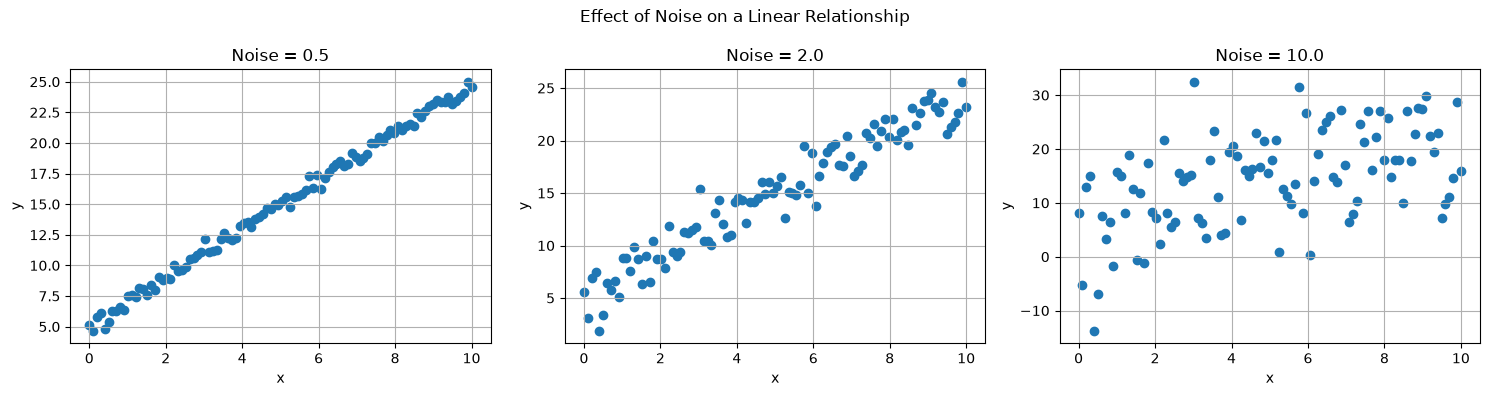


Recovered parameters:
Noise 0.5  -> slope = 1.9790, intercept = 5.0797
Noise 2.0  -> slope = 1.9161, intercept = 5.3190
Noise 10.0 -> slope = 1.5805, intercept = 6.5949

True slope: 2.0
Low-noise error: 0.020976418351862147
Medium-noise error: 0.08390567340744859
High-noise error: 0.4195283670372434

Overlapping clusters shape:
(2, 100, 2)

Separated clusters shape:
(2, 100, 2)


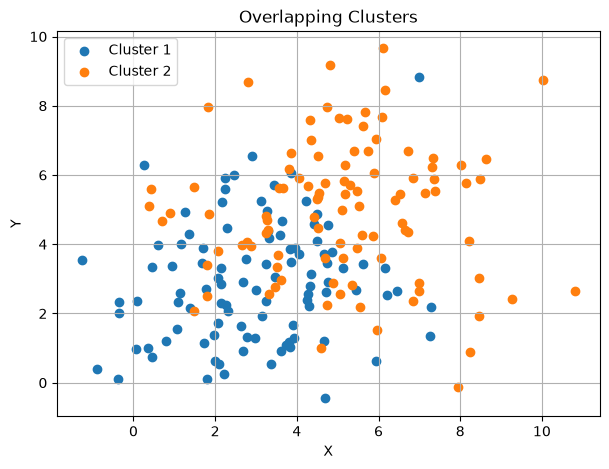

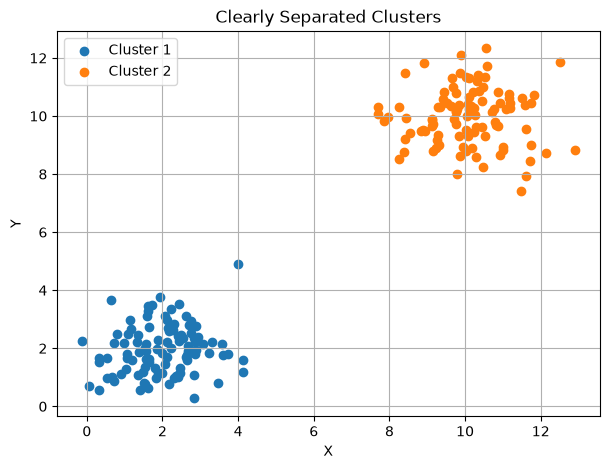

In [4]:
# TASK 04
# Generate synthetic 2D data with controllable noise

import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# TASK 04 — Synthetic 2D Data
# =========================================================


# ---------------------------------------------------------
# 1. Function to generate noisy straight-line data
# ---------------------------------------------------------
def make_line(n, slope, intercept, noise, seed=0):
    """
    Generate points around a straight line.

    y = slope * x + intercept + random noise
    """
    rng = np.random.default_rng(seed)

    x = np.linspace(0, 10, n)

    y = slope * x + intercept + rng.normal(0, noise, n)

    return x, y


# ---------------------------------------------------------
# 2. Generate three datasets with different noise levels
# ---------------------------------------------------------

n = 100
slope = 2.0
intercept = 5.0

x_low, y_low = make_line(
    n, slope, intercept, noise=0.5, seed=42
)

x_medium, y_medium = make_line(
    n, slope, intercept, noise=2.0, seed=42
)

x_high, y_high = make_line(
    n, slope, intercept, noise=10.0, seed=42
)


print("Dataset shapes:")
print("Low noise:", x_low.shape, y_low.shape)
print("Medium noise:", x_medium.shape, y_medium.shape)
print("High noise:", x_high.shape, y_high.shape)


# ---------------------------------------------------------
# 3. Plot all three datasets side by side
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(x_low, y_low)
axes[0].set_title("Noise = 0.5")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].grid(True)

axes[1].scatter(x_medium, y_medium)
axes[1].set_title("Noise = 2.0")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].grid(True)

axes[2].scatter(x_high, y_high)
axes[2].set_title("Noise = 10.0")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].grid(True)

plt.suptitle("Effect of Noise on a Linear Relationship")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 4. Recover slope using np.polyfit()
# ---------------------------------------------------------

low_slope, low_intercept = np.polyfit(x_low, y_low, 1)

medium_slope, medium_intercept = np.polyfit(
    x_medium, y_medium, 1
)

high_slope, high_intercept = np.polyfit(
    x_high, y_high, 1
)


print("\nRecovered parameters:")
print(
    f"Noise 0.5  -> slope = {low_slope:.4f}, "
    f"intercept = {low_intercept:.4f}"
)

print(
    f"Noise 2.0  -> slope = {medium_slope:.4f}, "
    f"intercept = {medium_intercept:.4f}"
)

print(
    f"Noise 10.0 -> slope = {high_slope:.4f}, "
    f"intercept = {high_intercept:.4f}"
)


# ---------------------------------------------------------
# 5. Compare recovered slopes
# ---------------------------------------------------------

print("\nTrue slope:", slope)

print("Low-noise error:",
      abs(low_slope - slope))

print("Medium-noise error:",
      abs(medium_slope - slope))

print("High-noise error:",
      abs(high_slope - slope))


# ---------------------------------------------------------
# 6. Generate 2D clusters
# ---------------------------------------------------------

def make_clusters(n, centres, spread, seed=0):
    """
    Generate 2D points around given centre points.

    Parameters
    ----------
    n : int
        Number of points per cluster.
    centres : array-like
        Cluster centre coordinates, shape (number_of_clusters, 2).
    spread : float
        Standard deviation of the generated points.
    seed : int
        Random seed.
    """
    rng = np.random.default_rng(seed)

    centres = np.asarray(centres)

    # Generate all points at once.
    points = (
        centres[:, np.newaxis, :]
        + rng.normal(
            0,
            spread,
            size=(len(centres), n, 2)
        )
    )

    return points


# ---------------------------------------------------------
# 7. Clearly overlapping clusters
# ---------------------------------------------------------

overlap_centres = np.array([
    [3, 3],
    [5, 5]
])

overlap = make_clusters(
    n=100,
    centres=overlap_centres,
    spread=2.0,
    seed=42
)

print("\nOverlapping clusters shape:")
print(overlap.shape)
# Expected: (2, 100, 2)


# ---------------------------------------------------------
# 8. Clearly separated clusters
# ---------------------------------------------------------

separate_centres = np.array([
    [2, 2],
    [10, 10]
])

separate = make_clusters(
    n=100,
    centres=separate_centres,
    spread=1.0,
    seed=42
)

print("\nSeparated clusters shape:")
print(separate.shape)
# Expected: (2, 100, 2)


# ---------------------------------------------------------
# 9. Plot overlapping clusters
# ---------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.scatter(
    overlap[0, :, 0],
    overlap[0, :, 1],
    label="Cluster 1"
)

plt.scatter(
    overlap[1, :, 0],
    overlap[1, :, 1],
    label="Cluster 2"
)

plt.title("Overlapping Clusters")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 10. Plot separated clusters
# ---------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.scatter(
    separate[0, :, 0],
    separate[0, :, 1],
    label="Cluster 1"
)

plt.scatter(
    separate[1, :, 0],
    separate[1, :, 1],
    label="Cluster 2"
)

plt.title("Clearly Separated Clusters")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

Part B — the numerical pitfalls exercise

In [5]:
# TASK 05
# Break things on purpose

import numpy as np


# =========================================================
# TASK 05 — Numerical Pitfalls
# =========================================================


# ---------------------------------------------------------
# 1. Floating-point representation error
# ---------------------------------------------------------

result = 0.1 + 0.2

print("0.1 + 0.2:")
print(repr(result))

print("\nIs 0.1 + 0.2 exactly equal to 0.3?")
print(result == 0.3)

print("\nAre they approximately equal?")
print(np.isclose(result, 0.3))

# Explanation:
# Decimal numbers such as 0.1 and 0.2 cannot always be
# represented exactly in binary floating-point format.
# Therefore, the stored result can be slightly different
# from the mathematical value 0.3.


# ---------------------------------------------------------
# 2. Two more examples of floating-point error
# ---------------------------------------------------------

example_1 = 0.1 + 0.7
example_2 = 0.2 + 0.4

print("\nAdditional floating-point examples:")

print("0.1 + 0.7 =", repr(example_1))
print("Expected =", repr(0.8))

print("\n0.2 + 0.4 =", repr(example_2))
print("Expected =", repr(0.6))


# Detect:
# Use np.isclose() instead of exact == comparisons.
#
# Avoid:
# Use tolerances for floating-point comparisons and avoid
# assuming decimal values have exact binary representations.


# ---------------------------------------------------------
# 3. Integer overflow with int8
# ---------------------------------------------------------

small = np.array([1, 2, 3], dtype=np.int8)

overflow_result = small * 100

print("\nint8 multiplication:")
print("Original:", small)
print("Result:", overflow_result)
print("dtype:", overflow_result.dtype)

# int8 can store only values from -128 to 127.
# Multiplying positive numbers can exceed 127, causing
# integer overflow and unexpected negative values.

# Detect:
# Check dtype and validate that calculations stay within
# the dtype's numerical range.
#
# Avoid:
# Use a larger integer dtype such as int32 or int64.


# ---------------------------------------------------------
# 4. Float32 precision loss
# ---------------------------------------------------------

x = np.float32(1e8)

difference = np.float32(x + 1) - x

print("\nfloat32 precision loss:")
print("x:", x)
print("x + 1 - x:", difference)

# At sufficiently large values, float32 does not have enough
# precision to represent every integer. Therefore, adding 1
# may produce no observable change.

# Detect:
# Check dtype and test precision-sensitive operations with
# representative values.
#
# Avoid:
# Use float64 when greater numerical precision is required.


# ---------------------------------------------------------
# 5. Catastrophic cancellation
# ---------------------------------------------------------

large_a = np.float32(1e8)
large_b = np.float32(1e8 - 10)

float32_difference = large_a - large_b

print("\nCatastrophic cancellation:")
print("float32 a:", large_a)
print("float32 b:", large_b)
print("float32 difference:", float32_difference)

# Compare with float64 using the same mathematical values.
large_a_64 = np.float64(1e8)
large_b_64 = np.float64(1e8 - 10)

float64_difference = large_a_64 - large_b_64

print("float64 difference:", float64_difference)

# When two large, nearly equal floating-point values are
# subtracted, significant precision can be lost.
#
# Detect:
# Compare results against higher precision or a known reference.
#
# Avoid:
# Reformulate the calculation mathematically when possible,
# or use a higher-precision dtype.


# ---------------------------------------------------------
# 6. Summing one million small floats
# ---------------------------------------------------------

n = 1_000_000

small_value = np.float32(0.000001)

values = np.full(n, small_value, dtype=np.float32)

# Exact mathematical answer
exact_answer = 1.0

sum_float32 = np.sum(values, dtype=np.float32)
sum_float64 = np.sum(values, dtype=np.float64)

error_float32 = abs(float(sum_float32) - exact_answer)
error_float64 = abs(float(sum_float64) - exact_answer)

print("\nMillion-small-floats experiment:")

print("Exact answer:", exact_answer)

print("float32 sum:", repr(sum_float32))
print("float32 error:", error_float32)

print("float64 sum:", repr(sum_float64))
print("float64 error:", error_float64)


# Determine which result is closer.
if error_float32 < error_float64:
    print("\nfloat32 is closer.")
elif error_float64 < error_float32:
    print("\nfloat64 is closer.")
else:
    print("\nBoth have the same error.")


# ---------------------------------------------------------
# 7. Summary of numerical pitfalls
# ---------------------------------------------------------

print("\nNumerical Pitfalls Summary")

print("""
1. Floating-point equality
   Detect: use np.isclose() for approximate comparisons.
   Avoid: do not rely on exact == for calculated floats.

2. Integer overflow
   Detect: check integer dtype and expected numerical range.
   Avoid: use a larger integer dtype when necessary.

3. float32 precision loss
   Detect: check dtype and test precision-sensitive operations.
   Avoid: use float64 when more precision is required.

4. Catastrophic cancellation
   Detect: compare against a higher-precision/reference result.
   Avoid: reformulate calculations or use higher precision.

5. Accumulation error
   Detect: compare sums with a higher-precision reference.
   Avoid: accumulate using float64 when appropriate.
""")

0.1 + 0.2:
0.30000000000000004

Is 0.1 + 0.2 exactly equal to 0.3?
False

Are they approximately equal?
True

Additional floating-point examples:
0.1 + 0.7 = 0.7999999999999999
Expected = 0.8

0.2 + 0.4 = 0.6000000000000001
Expected = 0.6

int8 multiplication:
Original: [1 2 3]
Result: [100 -56  44]
dtype: int8

float32 precision loss:
x: 1e+08
x + 1 - x: 0.0

Catastrophic cancellation:
float32 a: 1e+08
float32 b: 9.999999e+07
float32 difference: 8.0
float64 difference: 10.0

Million-small-floats experiment:
Exact answer: 1.0
float32 sum: np.float32(1.0)
float32 error: 0.0
float64 sum: np.float64(0.9999999974752427)
float64 error: 2.5247572921216488e-09

float32 is closer.

Numerical Pitfalls Summary

1. Floating-point equality
   Detect: use np.isclose() for approximate comparisons.
   Avoid: do not rely on exact == for calculated floats.

2. Integer overflow
   Detect: check integer dtype and expected numerical range.
   Avoid: use a larger integer dtype when necessary.

3. float32 p

Part C — put it together

Original data shape: (300, 4)

Feature means before standardisation:
[-0.0410789  -0.04034656 -0.08745399  0.04261755]

Feature standard deviations before standardisation:
[0.92872011 0.89886681 1.0161616  0.97770232]

Standardised data shape:
(300, 4)

Means after standardisation:
[ 1.72084569e-17  7.40148683e-19 -5.92118946e-18  1.48029737e-17]
Means approximately zero:
True

Standard deviations after standardisation:
[1. 1. 1. 1.]
Standard deviations approximately one:
True

Covariance matrix:
[[ 1.00334448  0.94407023  0.11046266  0.02645839]
 [ 0.94407023  1.00334448  0.05943294 -0.01137136]
 [ 0.11046266  0.05943294  1.00334448  0.03275312]
 [ 0.02645839 -0.01137136  0.03275312  1.00334448]]

Covariance matrix shape:
(4, 4)

Is covariance matrix symmetric?
True

Eigenvalues before sorting:
[0.05719794 0.96381287 1.02966816 1.96269897]

Eigenvectors before sorting:
[[ 0.70814234 -0.05333495 -0.03224123 -0.70331381]
 [-0.70455788 -0.07083172 -0.09515891 -0.69966124]
 [-0.03748456  

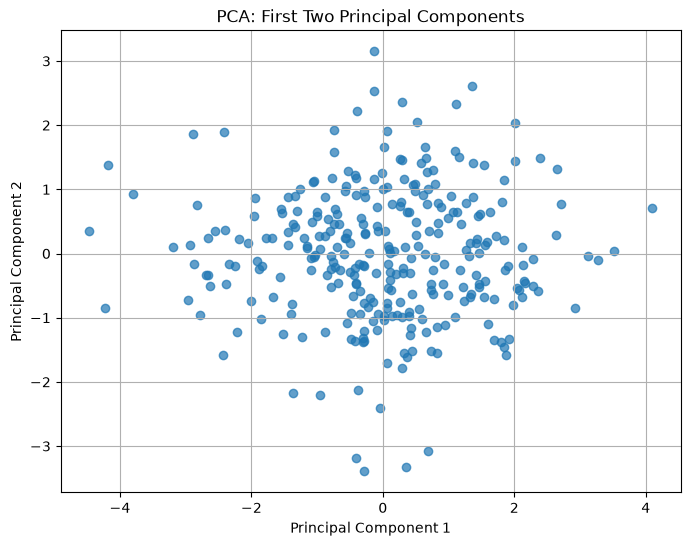


Covariance matrix from np.cov():
[[ 1.00334448  0.94407023  0.11046266  0.02645839]
 [ 0.94407023  1.00334448  0.05943294 -0.01137136]
 [ 0.11046266  0.05943294  1.00334448  0.03275312]
 [ 0.02645839 -0.01137136  0.03275312  1.00334448]]

Do manually calculated covariance matrices match?
True

Our sorted eigenvalues:
[1.96269897 1.02966816 0.96381287 0.05719794]

np.cov() eigenvalues:
[1.96269897 1.02966816 0.96381287 0.05719794]

Do eigenvalues match?
True


In [6]:
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# TASK 06 — PCA BY HAND
# =========================================================

# ---------------------------------------------------------
# 1. Generate synthetic data
# ---------------------------------------------------------

rng = np.random.default_rng(42)

n = 300

# Feature 1: base feature
f1 = rng.normal(0, 1, n)

# Feature 2: strongly correlated with feature 1
f2 = f1 * 0.9 + rng.normal(0, 0.3, n)

# Feature 3: weakly correlated with feature 1
f3 = f1 * 0.2 + rng.normal(0, 1.0, n)

# Feature 4: independent
f4 = rng.normal(0, 1, n)

# Combine all features into one matrix
X = np.column_stack([f1, f2, f3, f4])

print("Original data shape:", X.shape)
# Expected: (300, 4)


# ---------------------------------------------------------
# 2. Standardise every feature
# ---------------------------------------------------------

# Calculate mean of each feature
feature_means = X.mean(axis=0)

# Calculate standard deviation of each feature
feature_stds = X.std(axis=0)

print("\nFeature means before standardisation:")
print(feature_means)

print("\nFeature standard deviations before standardisation:")
print(feature_stds)


# Standardise:
# mean = 0
# standard deviation = 1
Xs = (X - feature_means) / feature_stds

print("\nStandardised data shape:")
print(Xs.shape)


# Verify means are approximately zero
standardised_means = Xs.mean(axis=0)

print("\nMeans after standardisation:")
print(standardised_means)

print("Means approximately zero:")
print(np.allclose(standardised_means, 0))


# Verify standard deviations are approximately one
standardised_stds = Xs.std(axis=0)

print("\nStandard deviations after standardisation:")
print(standardised_stds)

print("Standard deviations approximately one:")
print(np.allclose(standardised_stds, 1))


# ---------------------------------------------------------
# 3. Compute covariance matrix manually
# ---------------------------------------------------------

cov_matrix = (Xs.T @ Xs) / (n - 1)

print("\nCovariance matrix:")
print(cov_matrix)

print("\nCovariance matrix shape:")
print(cov_matrix.shape)
# Expected: (4, 4)

# A covariance matrix should be symmetric.
print("\nIs covariance matrix symmetric?")
print(np.allclose(cov_matrix, cov_matrix.T))


# ---------------------------------------------------------
# 4. Find eigenvalues and eigenvectors
# ---------------------------------------------------------

# Covariance matrices are symmetric, so eigh() is appropriate.
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("\nEigenvalues before sorting:")
print(eigenvalues)

print("\nEigenvectors before sorting:")
print(eigenvectors)


# ---------------------------------------------------------
# 5. Sort eigenvalues in descending order
# ---------------------------------------------------------

sort_indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sort_indices]
eigenvectors = eigenvectors[:, sort_indices]

print("\nSorted eigenvalues:")
print(eigenvalues)

print("\nSorted eigenvectors:")
print(eigenvectors)

print("\nEigenvalues shape:")
print(eigenvalues.shape)
# Expected: (4,)

print("Eigenvectors shape:")
print(eigenvectors.shape)
# Expected: (4, 4)


# ---------------------------------------------------------
# 6. Explained variance ratio
# ---------------------------------------------------------

explained_variance_ratio = (
    eigenvalues / eigenvalues.sum()
)

print("\nExplained variance ratio:")
print(explained_variance_ratio)

print("\nExplained variance percentage:")
print(explained_variance_ratio * 100)


# Cumulative explained variance
cumulative_variance = np.cumsum(
    explained_variance_ratio
)

print("\nCumulative explained variance:")
print(cumulative_variance)

print("\nCumulative explained variance percentage:")
print(cumulative_variance * 100)


# ---------------------------------------------------------
# 7. Number of components needed for 90% variance
# ---------------------------------------------------------

components_90 = np.argmax(
    cumulative_variance >= 0.90
) + 1

print(
    "\nNumber of components needed for 90% variance:",
    components_90
)


# ---------------------------------------------------------
# 8. Project data onto first two principal components
# ---------------------------------------------------------

# First two eigenvectors are the principal directions.
principal_vectors = eigenvectors[:, :2]

print("\nPrincipal vectors shape:")
print(principal_vectors.shape)
# Expected: (4, 2)


# Project standardised data onto first two components.
X_pca = Xs @ principal_vectors

print("\nPCA projected data shape:")
print(X_pca.shape)
# Expected: (300, 2)


# ---------------------------------------------------------
# 9. Plot the first two principal components
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: First Two Principal Components")
plt.grid(True)

plt.show()


# ---------------------------------------------------------
# 10. Compare with np.cov()
# ---------------------------------------------------------

numpy_covariance = np.cov(Xs.T)

print("\nCovariance matrix from np.cov():")
print(numpy_covariance)

print("\nDo manually calculated covariance matrices match?")
print(np.allclose(cov_matrix, numpy_covariance))


# Calculate eigenvalues from np.cov() for comparison
numpy_eigenvalues, _ = np.linalg.eigh(numpy_covariance)

numpy_eigenvalues = numpy_eigenvalues[::-1]

print("\nOur sorted eigenvalues:")
print(eigenvalues)

print("\nnp.cov() eigenvalues:")
print(numpy_eigenvalues)

print("\nDo eigenvalues match?")
print(np.allclose(eigenvalues, numpy_eigenvalues))